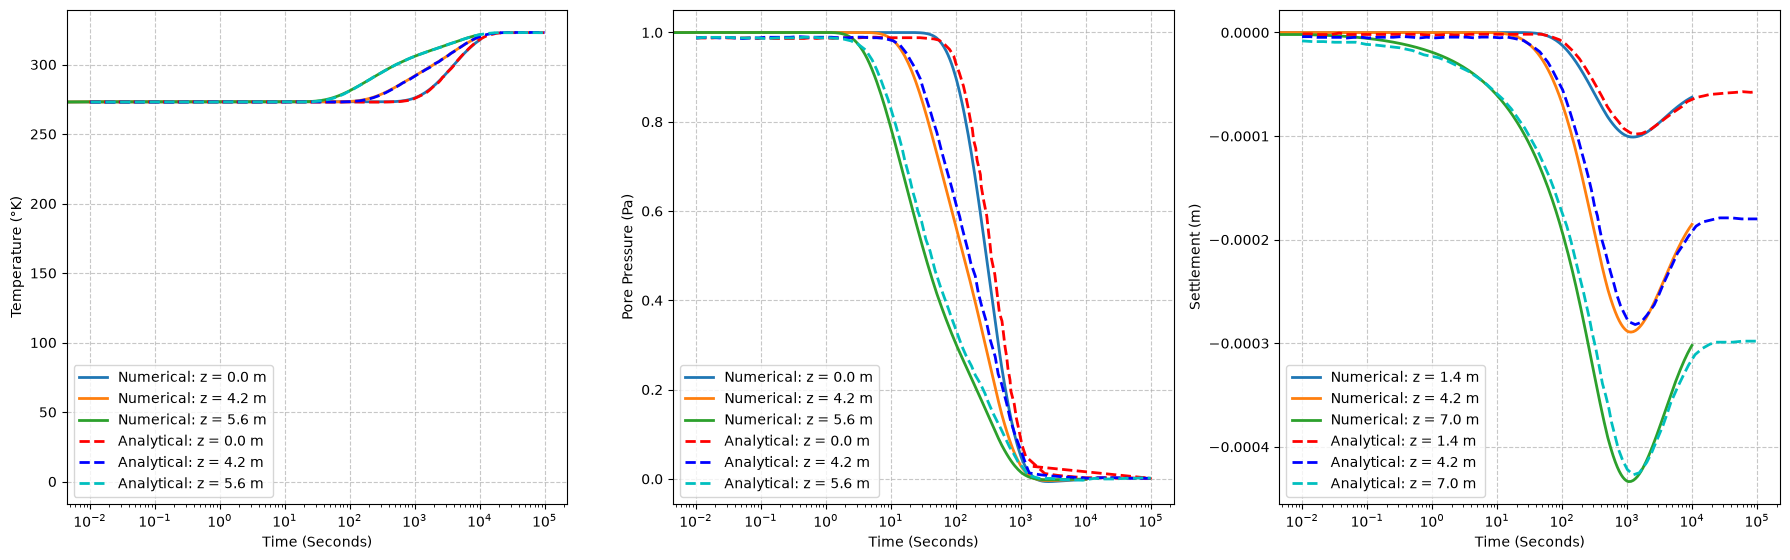

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import logging
from typing import Dict, Tuple, Optional, Union

# Configure logger
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

def process_dataset(
    file_path: str,
    conversion_factor: Optional[float] = None,
    convert_kelvin: bool = False,
    skip_rows: bool = False,
    data_column: str = 'temperature'
) -> pd.DataFrame:
    """
    Process dataset from CSV file.
    
    Args:
        file_path: Path to the CSV file
        conversion_factor: Factor to convert time units (if needed)
        convert_kelvin: Whether to convert temperature from Kelvin to Celsius
        skip_rows: Whether to skip initial rows in the CSV
        data_column: Name of the data column in the CSV
        
    Returns:
        Processed DataFrame with standardized columns
    """
    try:
        # Read the CSV file
        skiprows = 1 if skip_rows else None
        df = pd.read_csv(file_path, skiprows=skiprows)
        
        # Standardize the time column
        if 'time' in df.columns:
            time_col = 'time'
        elif 'Time' in df.columns:
            time_col = 'Time'
        else:
            # If no time column is found, use the first column
            time_col = df.columns[0]
            logger.warning(f"No standard time column found. Using '{time_col}' instead.")
        
        # Convert time if needed
        if conversion_factor:
            df['time_years'] = df[time_col] * conversion_factor
        else:
            df['time_years'] = df[time_col]
        
        # Process data column
        if data_column in df.columns:
            if convert_kelvin and 'temp' in data_column.lower():
                df['processed_data'] = df[data_column] - 273.15
            else:
                df['processed_data'] = df[data_column]
        else:
            logger.error(f"Data column '{data_column}' not found in {file_path}")
            return None
            
        return df
        
    except Exception as e:
        logger.error(f"Error processing {file_path}: {str(e)}")
        return None

def create_subplot(
    ax,
    datasets: Dict[str, Tuple[Optional[pd.DataFrame], str, str, Optional[str], bool]],
    title: str,
    ylabel: str,
    use_log_scale: bool = True
) -> None:
    """
    Create a subplot with data from multiple datasets.
    
    Args:
        ax: Matplotlib axes object for plotting
        datasets: Dictionary mapping dataset names to tuples containing:
                 (DataFrame, time_column, line_style, marker_style, plot_enabled)
        title: Title for the subplot
        ylabel: Y-axis label
        use_log_scale: Whether to use logarithmic scale for x-axis
    """
    for name, (df, time_col, style, marker, plot_enabled) in datasets.items():
        # Skip if plotting is disabled for this dataset or df is None
        if not plot_enabled or df is None:
            logger.info(f"Skipping plot for {name} - plot_enabled={plot_enabled}, df exists={df is not None}")
            continue
            
        if time_col in df.columns and 'processed_data' in df.columns:
            if marker:
                ax.scatter(df[time_col], df['processed_data'], 
                          marker=marker, label=name, alpha=0.7)
            else:
                ax.plot(df[time_col], df['processed_data'], 
                      style, label=name, linewidth=2)
        else:
            logger.warning(f"Missing required columns in {name}. Needs {time_col} and processed_data")
    
    if use_log_scale:
        ax.set_xscale('log')
    
    ax.set_xlabel('Time (Seconds)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

def main():
    # Define time conversion constants
    seconds_per_year = 365.25 * 24 * 60 * 60  # seconds to years
    
    # Base path for all files
    # base_path = '/Users/saeedvdi/Library/CloudStorage/OneDrive-ConcordiaUniversity-Canada/Concordia_Masters_Files/Thesis/Paper_Journal/2ndPaper_Feb18th/Simulation/CZM/Validation/Feb19/terzaghi/'
    base_path = ''
    # Data sources for all three plots
    file_paths = {
        # Main data file
        'main_data': base_path + 'THM_Consolidation_ghasemi.csv',
        
        # Temperature files
        'temp_0m': base_path + 'ValidationData/thermoConsolidationTemp_0m.csv',
        'temp_4p2m': base_path + 'ValidationData/thermoConsolidationTemp_4p2m.csv',
        'temp_5p6m': base_path + 'ValidationData/thermoConsolidationTemp_5p6m.csv',
        
        # Pressure files
        'pressure_0m': base_path + 'ValidationData/thermoConsolidationPressure_0m.csv',
        'pressure_4p2m': base_path + 'ValidationData/thermoConsolidationPressure_4p2m.csv',
        'pressure_5p6m': base_path + 'ValidationData/thermoConsolidationPressure_5p6m.csv',
        
        # Displacement files
        'disp_1p4m': base_path + 'ValidationData/thermoConsolidationDisp_1p4m.csv',
        'disp_4p2m': base_path + 'ValidationData/thermoConsolidationDisp_4p2m.csv',
        'disp_7m': base_path + 'ValidationData/thermoConsolidationDisp_7m.csv',
    }
    
    # Dataset configurations for temperature plot
    temp_datasets = {
        'Numerical: z = 0.0 m': (
            process_dataset(file_paths['main_data'], data_column='t0'),
            'time', '', '', True
        ),
        'Numerical: z = 4.2 m': (
            process_dataset(file_paths['main_data'], data_column='t2_4_2'),
            'time', '', '', True
        ),
        'Numerical: z = 5.6 m': (
            process_dataset(file_paths['main_data'], data_column='t_5_6'),
            'time', '', '', True
        ),
        'Analytical: z = 0.0 m': (
            process_dataset(file_paths['temp_0m'], data_column='temp_k'),
            'time', '--r', None, True
        ),
        'Analytical: z = 4.2 m': (
            process_dataset(file_paths['temp_4p2m'], data_column='temp_k'),
            'time', '--b', None, True
        ),
        'Analytical: z = 5.6 m': (
            process_dataset(file_paths['temp_5p6m'], data_column='temp_k'),
            'time', '--c', None, True
        ),
    }
    
    # Dataset configurations for pore pressure plot
    pressure_datasets = {
        'Numerical: z = 0.0 m': (
            process_dataset(file_paths['main_data'], data_column='p0'),
            'time', '', '', True
        ),
        'Numerical: z = 4.2 m': (
            process_dataset(file_paths['main_data'], data_column='p2_4_2'),
            'time', '', '', True
        ),
        'Numerical: z = 5.6 m': (
            process_dataset(file_paths['main_data'], data_column='p_5_6'),
            'time', '', '', True
        ),
        'Analytical: z = 0.0 m': (
            process_dataset(file_paths['pressure_0m'], data_column='porepressure'),
            'time', '--r', None, True
        ),
        'Analytical: z = 4.2 m': (
            process_dataset(file_paths['pressure_4p2m'], data_column='porepressure'),
            'time', '--b', None, True
        ),
        'Analytical: z = 5.6 m': (
            process_dataset(file_paths['pressure_5p6m'], data_column='porepressure'),
            'time', '--c', None, True
        ),
    }
    
    # Dataset configurations for settlement plot
    settlement_datasets = {
        'Numerical: z = 1.4 m': (
            process_dataset(file_paths['main_data'], data_column='zdis_1_4'),
            'time', '', '', True
        ),
        'Numerical: z = 4.2 m': (
            process_dataset(file_paths['main_data'], data_column='zdisp_4_2'),
            'time', '', '', True
        ),
        'Numerical: z = 7.0 m': (
            process_dataset(file_paths['main_data'], data_column='zdisp_7'),
            'time', '', '', True
        ),
        'Analytical: z = 1.4 m': (
            process_dataset(file_paths['disp_1p4m'], data_column='disp_z_neg'),
            'time', '--r', None, True
        ),
        'Analytical: z = 4.2 m': (
            process_dataset(file_paths['disp_4p2m'], data_column='disp_z_neg'),
            'time', '--b', None, True
        ),
        'Analytical: z = 7.0 m': (
            process_dataset(file_paths['disp_7m'], data_column='disp_z_neg'),
            'time', '--c', None, True
        ),
    }
    
    # Create a figure with 3 subplots in a horizontal layout (1 row, 3 columns)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Create each subplot
    # create_subplot(axes[0], temp_datasets, 'Temperature Comparison', 'Temperature (°K)')
    # create_subplot(axes[1], pressure_datasets, 'Pore Pressure Comparison', 'Pore Pressure (Pa)')
    # create_subplot(axes[2], settlement_datasets, 'Settlement Comparison', 'Settlement (m)')
    create_subplot(axes[0], temp_datasets, '', 'Temperature (°K)')
    create_subplot(axes[1], pressure_datasets, '', 'Pore Pressure (Pa)')
    create_subplot(axes[2], settlement_datasets, '', 'Settlement (m)')
    
    # Add a common title for the entire figure
    # fig.suptitle('Model Comparison: Temperature, Pore Pressure, and Settlement', fontsize=16)
    
    # Adjust layout and spacing
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Make room for the suptitle
    
    # Save the figure
    plt.savefig('combined_comparison_horizontal.png', dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    main()